# Main scan: neighbour-based QA

Loads the LSR-corrected, pair-filtered, cell-combined output from
``main_scan_load.ipynb`` (via ``artifacts/scan_load_state.pkl``) and
runs neighbour-based QA on the calibrated brightness temperature
``T_B(v_LSR)``.  ``W`` is in K * km/s and the neighbour scale floor
is tuned for T_B-space residuals.

Pipeline order:

1. Apply the per-pol PDT-Fourier ``T_cal(t)`` from
   ``main_scan_calibration.ipynb`` to convert per-(session, cell, pol,
   LO) ``P_on`` / ``P_off`` scalars into ``T_sys_pol``, then
   ``T_B_pol(v) = R_pol(v) * T_sys_pol``.  A per-LO Y-factor floor
   (``Y = P_on / P_off >= Y_MIN``) rejects entries where the pol-0
   noise diode at LO 1419.86 MHz fails to inject above noise.
2. Plot the initial calibrated integrated-HI Mollweide
   (``W = int T_B dv``) before any pol QA.
3. **Cross-pol consistency**: for unpolarised HI, both pols should
   see ``T_B / 2``.  Cells whose pol-0 vs pol-1 spectra disagree by
   more than ``POL_DISAGREE_FRAC`` in the signal window are demoted
   to single-pol Stokes-I ``T_B = 2 * T_B_pol_good``, picking the
   surviving pol as the one with the lower ``T_sys``.
4. Neighbour-based QA on the post-pol-QA ``T_B``.

Outputs:
- ``artifacts/main_reobserve.json`` -- list of cells to reobserve
- ``artifacts/spectra_per_session.pdf`` -- per-session T_B(v_LSR)
  grids, with QA-flagged + insufficient-pairs cells excluded

Known limitations (not implemented):
- Edge-clipped recheck (cells whose HI emission wings reach the
  current LO pair's frequency-switched bandwidth edge).  Discussed
  in the report as future work.
- Absolute scale tie-down to Cygnus A.  Absolute scale currently
  inherits the EBHIS-anchored differential ``T_cal`` from
  ``main_scan_calibration.ipynb``.


In [7]:
from utils import (
    compute_cell_metrics,
    neighbor_qa,
    collect_reobserve,
)
from plotters import spectra_per_session_pdf

from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- Hardware ---
HPBW_DEG = 3.4

# --- T_sys per-LO Y-factor floor (rejects pol-0 entries where the
# noise diode at LO 1419.86 MHz fails to inject above noise) ---
Y_MIN = 1.01  # require P_on / P_off >= 1.01 per (session, cell, pol, LO)

# --- Cross-pol consistency demotion (signal-window mean) ---
POL_SIGNAL_V_LO_KMS = -80.0
POL_SIGNAL_V_HI_KMS = 60.0
POL_DISAGREE_FRAC = 0.10   # median |T_B_pol0 - T_B_pol1| / median(0.5*(pol0+pol1))
POL_AVG_FLOOR_K = 5.0      # noise floor for the denominator in K

# --- Per-cell metrics (T_B-space) ---
METRIC_MIN_VALID_CH = 8
METRIC_NOISE_V_MAX_KMS = -100.0
METRIC_SIGNAL_V_LO_KMS = -80.0
METRIC_SIGNAL_V_HI_KMS = 60.0
METRIC_SMOOTH_KERNEL = 5
METRIC_PEAK_MIN_SEP_KMS = 4.0
METRIC_PEAK_PROM_NSIGMA = 2.5
METRIC_MIN_NOISE_CH = 5

# --- Neighbor QA (operates on T_B; W is in K * km/s) ---
NEIGHBOR_MAX_SEP_DEG = 2.1
MIN_NEIGHBORS = 2
W_Z_THRESH = 3.0
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 1000.0  # K * km/s, tuned for T_B-space QA
PEAK_V_Z_THRESH = 3.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0
BIMODAL_MIN_RATIO = 0.68

# --- Pair-filter spectrum key (must match main_scan_load.ipynb) ---
PAIR_SPECTRUM_KEY = 'T_B_lsr'

# --- Paths ---
STATE_PATH = Path('artifacts/scan_load_state.pkl')
TCAL_DRIFT_PATH = Path('artifacts/tcal_drift_state.pkl')
REOBSERVE_PATH = Path('artifacts/main_reobserve.json')
SPECTRA_PDF_PATH = Path('artifacts/spectra_per_session.pdf')

get_ipython().run_line_magic('matplotlib', 'inline')

## 1. Load state from `main_scan_load.ipynb`

In [8]:
with open(STATE_PATH, 'rb') as f:
    state = pickle.load(f)

cell_combined = state['cell_combined']
viable_pairs_per_cell = state['viable_pairs_per_cell']
cells_insufficient_pairs = state['cells_insufficient_pairs']
v_lsr_overlap = state['v_lsr_overlap']
dv_kms = state['dv_kms']
sessions = state['sessions']
cell_scalars = state['cell_scalars']
F1_MHZ, F2_MHZ = state['lo_pair_mhz']

print(f'Loaded {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB)')
print(f'  {len(cell_combined)} science cells, '
      f'{len(cells_insufficient_pairs)} insufficient-pair cells')
print(f'  dv = {dv_kms:.3f} km/s, v_LSR span '
      f'[{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s, '
      f'{len(sessions)} sessions')
print(f'  {len(cell_scalars)} per-(session, cell) calibration scalars')


Loaded artifacts/scan_load_state.pkl (109.40 MB)
  2652 science cells, 0 insufficient-pair cells
  dv = 0.660 km/s, v_LSR span [-164, 132] km/s, 64 sessions
  2709 per-(session, cell) calibration scalars


## 2. Temperature calibration: T_B from per-pol PDT Fourier T_cal(t)

Evaluate the per-pol `Tcal_pol(t)` Fourier model produced by
`main_scan_calibration.ipynb` (loaded from
`artifacts/tcal_drift_state.pkl`) at each cell's median observation
time, convert the cached per-(session, cell, pol, LO) `P_on` /
`P_off` scalars to per-pol `T_sys_pol`, and combine with the per-pol
`R_pol(v_LSR)` from the load notebook to get `T_B(v_LSR)` in K.

The drift model is a discrete Fourier series of period 24 h in PDT
hour:

```
Tcal_pol(h_PDT) = a0 + sum_{k=1..K_pol} [a_k cos(2 pi k h/24)
                                          + b_k sin(2 pi k h/24)]
K_0 = 2, K_1 = 1
```

For each cell `(gl, gb)`:

1. For each session that observed the cell, look up the cached
   `t_median` and the per-pol band-averaged `P_on_pol{pi}_{lo}` /
   `P_off_pol{pi}_{lo}` from `cell_scalars`.
2. Fold `t_median -> h_PDT` (UTC + tz_offset_hours, mod 24), evaluate
   `Tcal_pol(h_PDT)` per pol via the Fourier coefficients.
3. Per pol per LO: `T_sys_pol_lo = Tcal_pol * P_off_pol_lo /
   (P_on_pol_lo - P_off_pol_lo)`; average the two LOs to a scalar
   `T_sys_pol` per (session, cell, pol).
4. Cell-level `T_sys_pol_cell` = pair-count-weighted mean across
   sessions where the cell was observed.
5. `cell['T_B_pol{pi}'] = R_pol{pi} * T_sys_pol{pi}_cell`;
   Stokes-I `cell['T_B'] = T_B_pol0 + T_B_pol1`.
6. Per-pair `pair['T_B_lsr_pol{pi}'] = R_lsr_pol{pi} * T_sys_pol{pi}`
   using the pair's own session; `T_B_lsr = sum_pi T_B_lsr_pol{pi}`.

Cells whose `t_median` falls outside the Fourier fit's training
window `[t_min, t_max]` are flagged `extrapolated` (Fourier
extrapolation is bounded because the model is periodic, but mark them
anyway so QA can warn).


In [9]:
from collections import defaultdict

with open(TCAL_DRIFT_PATH, 'rb') as f:
    drift_state = pickle.load(f)

PERIOD_H   = float(drift_state['period_hours'])
TZ_OFFSET  = float(drift_state['tz_offset_hours'])
N_HARM     = {int(k): int(v) for k, v in drift_state['n_harmonics'].items()}
T_MIN_FIT  = float(drift_state['t_min'])
T_MAX_FIT  = float(drift_state['t_max'])
TCAL_COEF  = {pi: np.asarray(drift_state['fit'][pi]['coef'], dtype=float)
              for pi in (0, 1)}

print(f"Loaded {TCAL_DRIFT_PATH}: pointing={drift_state['pointing']}, "
      f"K_0={N_HARM[0]}, K_1={N_HARM[1]}, "
      f"N_pol0={drift_state['fit'][0]['N']}, N_pol1={drift_state['fit'][1]['N']}, "
      f"period={PERIOD_H:.1f} h, tz_offset={TZ_OFFSET:+.1f} h")


def _hour_pdt(unix_t, tz_offset=TZ_OFFSET):
    # PDT hour-of-day in [0, 24).
    return ((np.asarray(unix_t, dtype=float) / 3600.0) + tz_offset) % 24.0


def _fourier_design(h, K, period=PERIOD_H):
    h = np.atleast_1d(np.asarray(h, dtype=float))
    cols = [np.ones_like(h)]
    for k in range(1, K + 1):
        omega = 2.0 * np.pi * k / period
        cols.append(np.cos(omega * h))
        cols.append(np.sin(omega * h))
    return np.column_stack(cols)


def eval_tcal_pol(unix_t, pi):
    # Tcal_pol(t) in K (scalar or array, matching input shape).
    h = _hour_pdt(unix_t)
    K = N_HARM[pi]
    X = _fourier_design(h, K)
    val = X @ TCAL_COEF[pi]
    return float(val[0]) if np.isscalar(unix_t) else val


# Per-LO rejection counter (driven by Y_MIN floor).
n_lo_rejected = {(pi, lo): 0 for pi in (0, 1) for lo in (F1_MHZ, F2_MHZ)}


def session_cell_tsys_per_pol(sess, gl, gb):
    # Returns ({pi: T_sys_pol}, extrapolated, t_median) for one cell/session.
    entry = cell_scalars.get((sess, gl, gb))
    if entry is None:
        return {0: np.nan, 1: np.nan}, False, np.nan
    t = float(entry['t_median'])
    extrap = (t < T_MIN_FIT) or (t > T_MAX_FIT)
    out = {}
    for pi in (0, 1):
        Tcal = eval_tcal_pol(t, pi)
        if not np.isfinite(Tcal):
            out[pi] = np.nan
            continue
        per_lo = []
        for lo in (F1_MHZ, F2_MHZ):
            P_on  = entry.get(f'P_on_pol{pi}_{lo:g}',  np.nan)
            P_off = entry.get(f'P_off_pol{pi}_{lo:g}', np.nan)
            if not (np.isfinite(P_on) and np.isfinite(P_off)):
                continue
            if P_off <= 0:
                continue
            dP = P_on - P_off
            if dP <= 0:
                continue
            # Y-factor floor: reject cases where the noise diode fails
            # to inject above noise (esp. pol 0 at LO 1419.86 MHz).
            if (P_on / P_off) < Y_MIN:
                n_lo_rejected[(pi, lo)] += 1
                continue
            per_lo.append(Tcal * P_off / dP)
        out[pi] = float(np.mean(per_lo)) if per_lo else np.nan
    return out, extrap, t


n_calibrated = 0
n_no_tsys    = 0
n_extrap     = 0
tsys_summary = {0: [], 1: []}

for (gl, gb), pairs in viable_pairs_per_cell.items():
    sess_counts = defaultdict(int)
    for pr in pairs:
        sess_counts[pr['session']] += 1

    num = {0: 0.0, 1: 0.0}
    den = {0: 0.0, 1: 0.0}
    any_extrap = False
    for sess, n_pr in sess_counts.items():
        tsys_dict, extrap, _ = session_cell_tsys_per_pol(sess, gl, gb)
        for pi in (0, 1):
            if np.isfinite(tsys_dict[pi]):
                num[pi] += tsys_dict[pi] * n_pr
                den[pi] += n_pr
        if extrap:
            any_extrap = True

    entry = cell_combined[(gl, gb)]
    have_any = False
    for pi in (0, 1):
        if den[pi] > 0:
            T_sys_cell = num[pi] / den[pi]
            entry[f'T_sys_pol{pi}'] = float(T_sys_cell)
            entry[f'T_B_pol{pi}']   = entry[f'R_pol{pi}'] * T_sys_cell
            tsys_summary[pi].append(T_sys_cell)
            have_any = True
        else:
            entry[f'T_sys_pol{pi}'] = np.nan
            entry[f'T_B_pol{pi}']   = np.full_like(entry[f'R_pol{pi}'], np.nan)

    # Stokes-I T_B = sum of pol-0 and pol-1 calibrated brightnesses.
    if np.isfinite(entry.get('T_sys_pol0', np.nan)) and \
       np.isfinite(entry.get('T_sys_pol1', np.nan)):
        entry['T_B'] = entry['T_B_pol0'] + entry['T_B_pol1']
        n_calibrated += 1
    else:
        entry['T_B'] = np.full_like(entry['R_pol0'], np.nan)
        n_no_tsys += 1
    entry['extrapolated'] = bool(any_extrap)
    if any_extrap:
        n_extrap += 1

    # Per-pair T_B_lsr (per-pol + summed) for the pair filter / spectra PDF.
    for pr in pairs:
        tsys_dict, _ext, _ = session_cell_tsys_per_pol(pr['session'], gl, gb)
        for pi in (0, 1):
            key_r = f'R_lsr_pol{pi}'
            ts = tsys_dict[pi]
            if np.isfinite(ts) and key_r in pr:
                pr[f'T_B_lsr_pol{pi}'] = pr[key_r] * ts
            else:
                pr[f'T_B_lsr_pol{pi}'] = np.full_like(pr.get(key_r,
                    np.zeros_like(v_lsr_overlap)), np.nan)
        if np.isfinite(tsys_dict[0]) and np.isfinite(tsys_dict[1]):
            pr['T_B_lsr'] = pr['T_B_lsr_pol0'] + pr['T_B_lsr_pol1']
        else:
            pr['T_B_lsr'] = np.full_like(v_lsr_overlap, np.nan)

print(f'T_B calibration: {n_calibrated} cells fully calibrated (both pols), '
      f'{n_no_tsys} with at least one pol missing T_sys, '
      f'{n_extrap} flagged extrapolated')
print(f'Y-factor floor (Y_MIN={Y_MIN}) per-LO rejections:')
for (pi, lo), n in n_lo_rejected.items():
    print(f'  pol {pi} LO {lo:g} MHz: {n} entries rejected')
for pi in (0, 1):
    arr = np.array(tsys_summary[pi])
    if arr.size:
        print(f'  pol {pi} T_sys: median={np.median(arr):.1f} K, '
              f'IQR [{np.percentile(arr, 25):.1f}, {np.percentile(arr, 75):.1f}] K, '
              f'range [{arr.min():.1f}, {arr.max():.1f}] K  (N={arr.size})')


Loaded artifacts/tcal_drift_state.pkl: pointing=recal_drift_bk, K_0=2, K_1=1, N_pol0=192, N_pol1=192, period=24.0 h, tz_offset=-7.0 h
T_B calibration: 2572 cells fully calibrated (both pols), 80 with at least one pol missing T_sys, 54 flagged extrapolated
Y-factor floor (Y_MIN=1.01) per-LO rejections:
  pol 0 LO 1419.86 MHz: 2555 entries rejected
  pol 0 LO 1421.14 MHz: 410 entries rejected
  pol 1 LO 1419.86 MHz: 0 entries rejected
  pol 1 LO 1421.14 MHz: 0 entries rejected
  pol 0 T_sys: median=108.3 K, IQR [81.5, 135.9] K, range [21.6, 270.2] K  (N=2572)
  pol 1 T_sys: median=93.6 K, IQR [83.2, 103.6] K, range [59.1, 151.9] K  (N=2652)


## 2b. Temperature-calibrated Mollweide map of $W = \int T_B\,dv$

Calibrated analogue of section 5 of `main_scan_load.ipynb`.
Velocity-integrating the Stokes-I `T_B(v_LSR)` per cell yields

$$ W(\ell, b)\;=\;\int T_B(\ell, b, v_{\rm LSR})\,dv_{\rm LSR}
   \quad [\mathrm{K\,km\,s^{-1}}],\qquad
   N_{\rm HI} = 1.823\times 10^{18}\,W\ \mathrm{cm^{-2}}. $$

Plotted on the same Mollweide projection as `main_scan_load.ipynb`
section 5, centred on `MOLL_CENTER_L = 120` deg.  Cells with missing
`T_sys` on either pol are omitted (NaN `T_B` -> NaN `W`).


T_B-calibrated cells with finite W: 2652 of 2652
  W (K * km/s): median=1546, IQR [954, 2590], range [0, 10592]


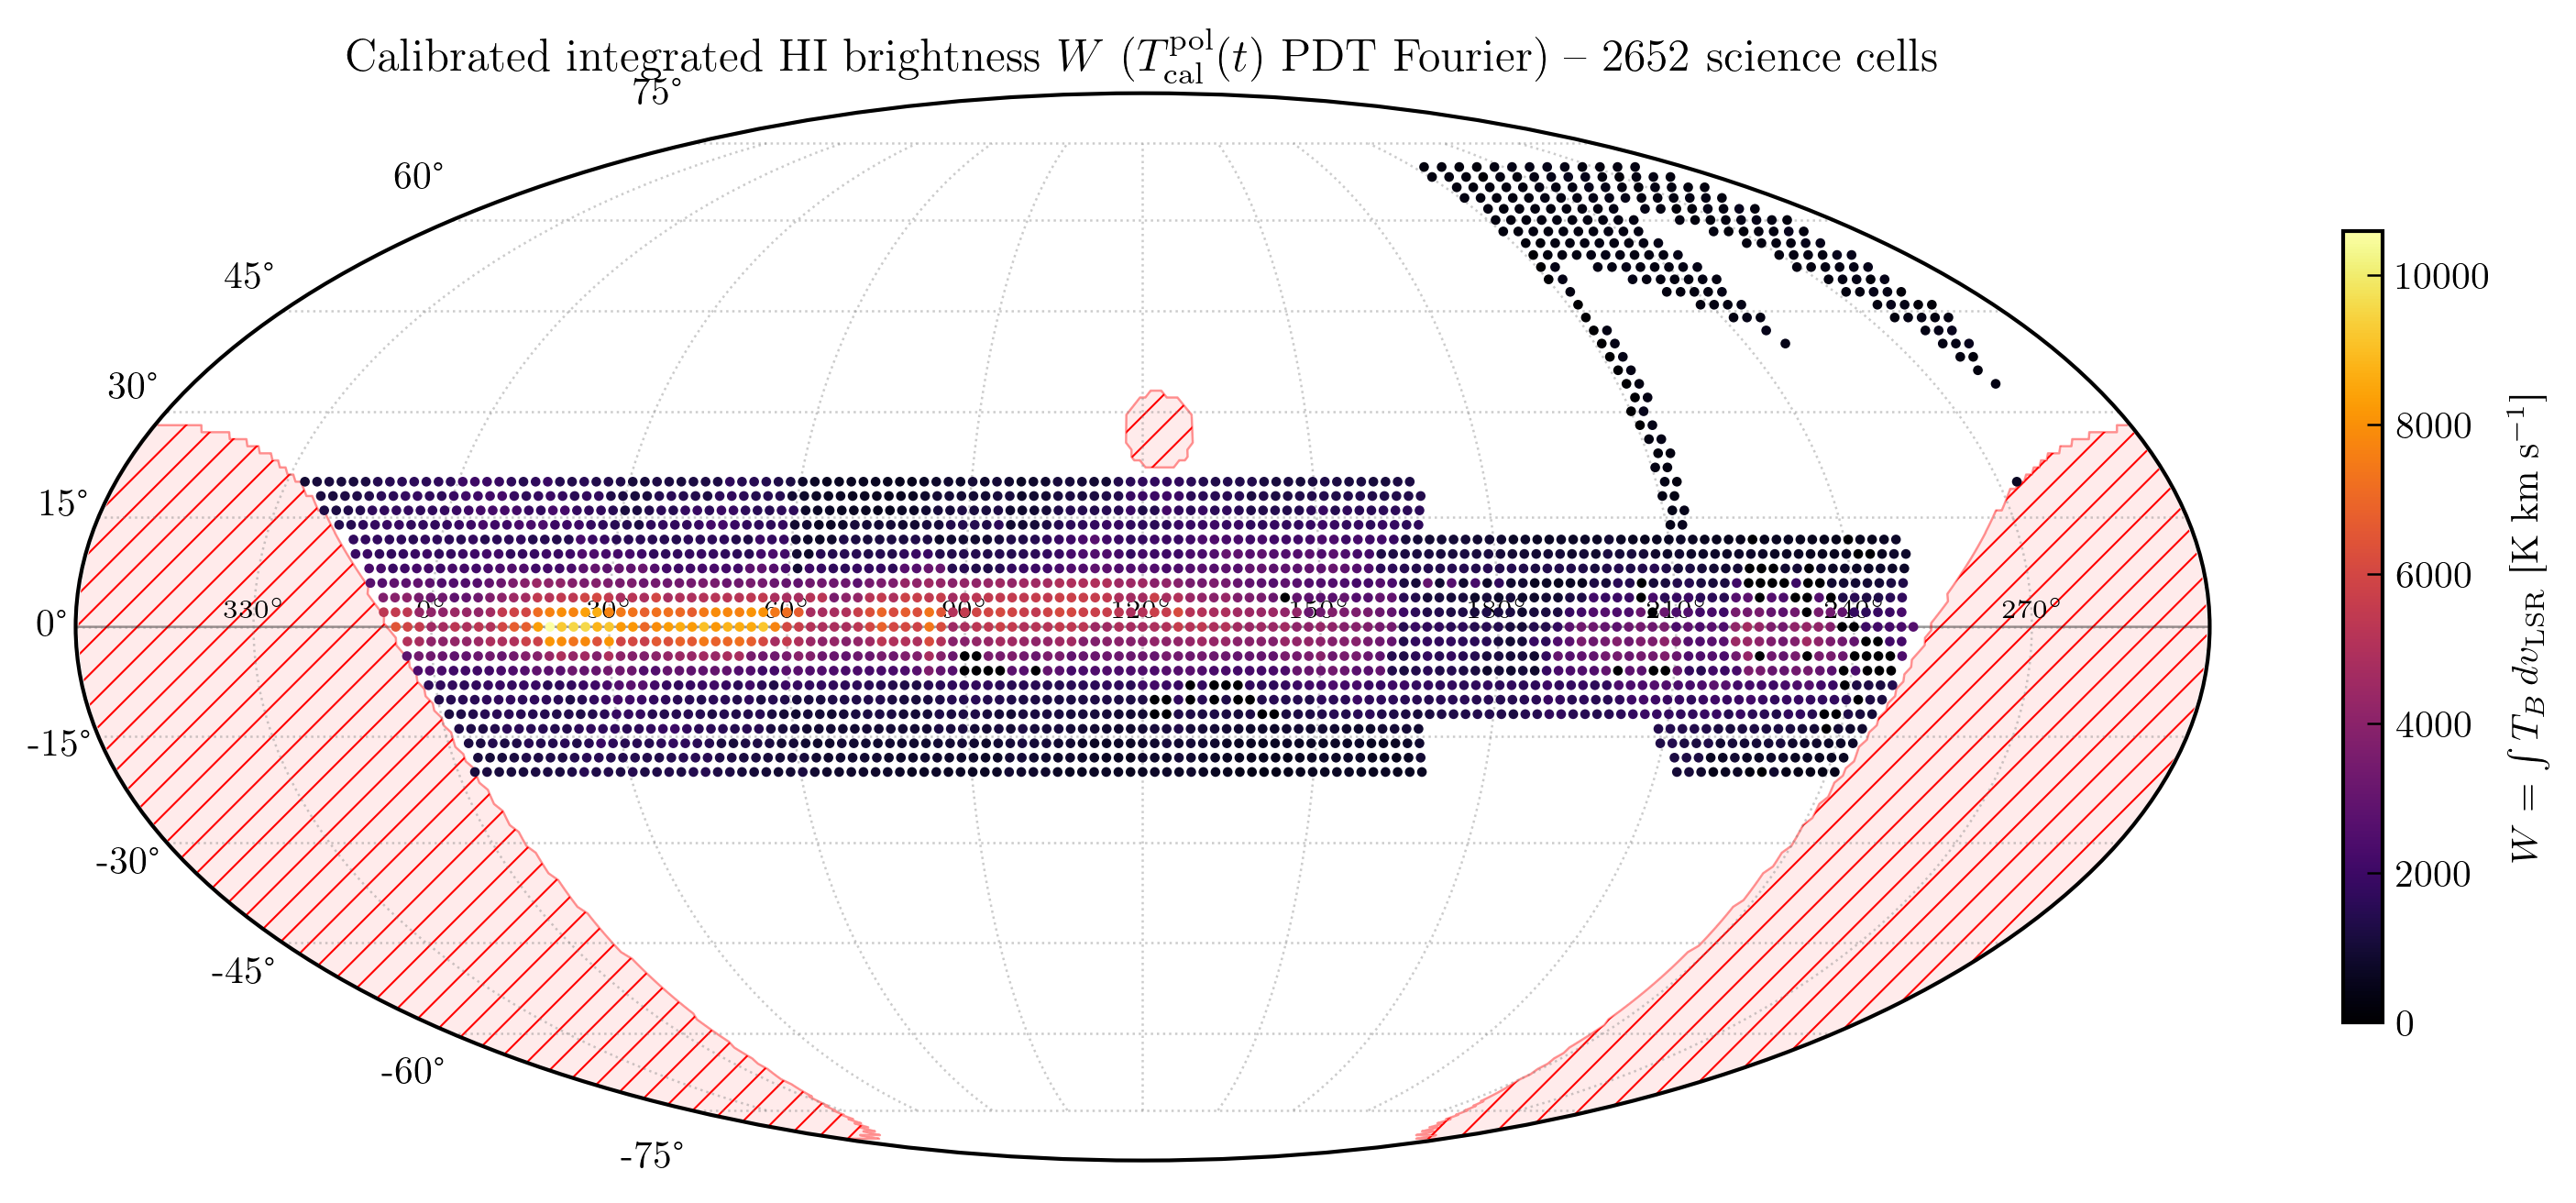

In [10]:
from plotters import plot_survey_mollweide
from utils import assemble_W_R_arrays
from ugradiolab.plotting import SS_MICRO, SS_FINE

MOLL_CENTER_L = 120.0

# Use Stokes-I T_B integrated over the LSR overlap.  assemble_W_R_arrays
# is spectrum-key agnostic: feeding it 'T_B' gives W in K * km/s.
arrs = assemble_W_R_arrays(cell_combined, dv_kms, spectrum_key='T_B')
gl_arr = arrs['gl']; gb_arr = arrs['gb']
W_TB   = arrs['W_R']; valid  = arrs['valid']

print(f'T_B-calibrated cells with finite W: {arrs["n_sci"]} of {len(cell_combined)}')
if valid.any():
    finite_W = W_TB[valid]
    print(f'  W (K * km/s): median={np.median(finite_W):.0f}, '
          f'IQR [{np.percentile(finite_W, 25):.0f}, '
          f'{np.percentile(finite_W, 75):.0f}], '
          f'range [{finite_W.min():.0f}, {finite_W.max():.0f}]')

fig, ax = plot_survey_mollweide(
    gl_arr[valid], gb_arr[valid], W_TB[valid],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \int T_B\, dv_{\rm LSR}$ [K km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=(f'Calibrated integrated HI brightness $W$ '
           f'($T_{{\\rm cal}}^{{\\rm pol}}(t)$ PDT Fourier) -- '
           f'{arrs["n_sci"]} science cells'),
)
plt.show()


## 2c. Cross-polarisation consistency demotion

For unpolarised HI the two linear pols should report identical
brightness temperatures up to noise:

$$ T_{B,\mathrm{pol0}}(v_\mathrm{LSR}) \approx T_{B,\mathrm{pol1}}(v_\mathrm{LSR})
   \approx \tfrac{1}{2} T_B^{\rm StokesI}(v_\mathrm{LSR}). $$

Large pol-0 vs pol-1 disagreement therefore flags a calibration
failure on the offending pol (typically pol 0 at LO 1419.86 MHz
when the noise diode fails to inject above noise -- see §2's
``Y_MIN`` per-LO rejections).

Procedure:

1. For each cell, compute over the signal window
   ``[POL_SIGNAL_V_LO_KMS, POL_SIGNAL_V_HI_KMS]``:

   ```
   diff = median |T_B_pol0(v) - T_B_pol1(v)|
   avg  = median 0.5 * (T_B_pol0(v) + T_B_pol1(v))
   pol_disagree_frac = diff / max(avg, POL_AVG_FLOOR_K)
   ```

2. If ``pol_disagree_frac > POL_DISAGREE_FRAC``, demote the cell to
   single-pol Stokes I:

   ```
   bad  = argmax(T_sys_pol)
   good = 1 - bad
   T_B  = 2 * T_B_pol{good}
   ```

   The factor of 2 restores the Stokes-I scale (each pol carries
   half the unpolarised brightness).  Per-pair ``T_B_lsr`` is
   updated to ``2 * T_B_lsr_pol{good}`` so the pair-level
   spectra inherit the demotion.

3. SNR cost: demoted cells lose a factor of ``sqrt(2)`` in
   sensitivity.  This is logged but not propagated as a per-cell
   uncertainty.


In [11]:
# Signal-window mask used for cross-pol consistency.
pol_sig_mask = (v_lsr_overlap >= POL_SIGNAL_V_LO_KMS) & \
               (v_lsr_overlap <= POL_SIGNAL_V_HI_KMS)

n_demoted = {0: 0, 1: 0}
n_evaluated = 0
demoted_cells = []
disagree_fracs = []

for (gl, gb), entry in cell_combined.items():
    tb0 = entry.get('T_B_pol0')
    tb1 = entry.get('T_B_pol1')
    entry['pol_demoted'] = None
    entry['pol_disagree_frac'] = np.nan
    if tb0 is None or tb1 is None:
        continue
    tb0 = np.asarray(tb0); tb1 = np.asarray(tb1)
    finite = np.isfinite(tb0) & np.isfinite(tb1) & pol_sig_mask
    if finite.sum() < METRIC_MIN_VALID_CH:
        continue

    diff = np.abs(tb0[finite] - tb1[finite])
    avg  = 0.5 * (tb0[finite] + tb1[finite])
    med_diff = float(np.median(diff))
    med_avg  = float(np.median(avg))
    frac = med_diff / max(med_avg, POL_AVG_FLOOR_K)

    entry['pol_disagree_frac'] = frac
    disagree_fracs.append(frac)
    n_evaluated += 1

    if frac > POL_DISAGREE_FRAC:
        ts0 = entry.get('T_sys_pol0', np.nan)
        ts1 = entry.get('T_sys_pol1', np.nan)
        if np.isfinite(ts0) and np.isfinite(ts1):
            bad = 0 if ts0 > ts1 else 1
        elif np.isfinite(ts0):
            bad = 1
        else:
            bad = 0
        good = 1 - bad
        entry['T_B'] = 2.0 * entry[f'T_B_pol{good}']
        entry['pol_demoted'] = bad
        n_demoted[bad] += 1
        demoted_cells.append((gl, gb, bad, frac, ts0, ts1))

# Propagate the per-cell demotion to per-pair T_B_lsr.
n_pair_updates = 0
for (gl, gb), pairs in viable_pairs_per_cell.items():
    entry = cell_combined.get((gl, gb))
    if entry is None:
        continue
    bad = entry.get('pol_demoted')
    if bad is None:
        continue
    good = 1 - bad
    gkey = f'T_B_lsr_pol{good}'
    for pr in pairs:
        if gkey in pr and np.isfinite(pr[gkey]).any():
            pr['T_B_lsr'] = 2.0 * pr[gkey]
            n_pair_updates += 1

print(f'Cross-pol consistency: {n_evaluated} cells evaluated '
      f'(signal window [{POL_SIGNAL_V_LO_KMS:.0f}, {POL_SIGNAL_V_HI_KMS:.0f}] km/s)')
if disagree_fracs:
    arr = np.array(disagree_fracs)
    print(f'  pol_disagree_frac: median={np.median(arr):.3f}, '
          f'IQR [{np.percentile(arr, 25):.3f}, {np.percentile(arr, 75):.3f}], '
          f'max={arr.max():.3f}')
print(f'  Demoted (frac > {POL_DISAGREE_FRAC}): '
      f'{n_demoted[0]} cells lost pol 0, {n_demoted[1]} cells lost pol 1 '
      f'({n_pair_updates} per-pair T_B_lsr updated)')

if demoted_cells:
    print('  Top 10 most-disagreeing demoted cells:')
    for gl, gb, bad, frac, ts0, ts1 in sorted(demoted_cells, key=lambda r: -r[3])[:10]:
        print(f"    l={gl:6.2f} b={gb:3d}  frac={frac:5.2f}  "
              f"T_sys=(pol0={ts0:7.1f}, pol1={ts1:7.1f}) K  -> dropped pol {bad}")


Cross-pol consistency: 2572 cells evaluated (signal window [-80, 60] km/s)
  pol_disagree_frac: median=0.222, IQR [0.157, 0.297], max=0.870
  Demoted (frac > 0.1): 1652 cells lost pol 0, 772 cells lost pol 1 (9912 per-pair T_B_lsr updated)
  Top 10 most-disagreeing demoted cells:
    l=168.37 b=-18  frac= 0.87  T_sys=(pol0=   34.9, pol1=   99.1) K  -> dropped pol 1
    l=360.00 b=  0  frac= 0.81  T_sys=(pol0=   91.6, pol1=  115.4) K  -> dropped pol 1
    l=163.29 b=-14  frac= 0.80  T_sys=(pol0=   39.7, pol1=   89.9) K  -> dropped pol 1
    l=103.84 b=  8  frac= 0.80  T_sys=(pol0=   60.5, pol1=   99.5) K  -> dropped pol 1
    l=165.35 b=-14  frac= 0.79  T_sys=(pol0=   31.8, pol1=   86.1) K  -> dropped pol 1
    l= 57.39 b= -8  frac= 0.77  T_sys=(pol0=   41.3, pol1=   94.8) K  -> dropped pol 1
    l= 61.43 b=  8  frac= 0.76  T_sys=(pol0=   26.6, pol1=  103.7) K  -> dropped pol 1
    l=167.85 b=-16  frac= 0.74  T_sys=(pol0=   34.4, pol1=   87.4) K  -> dropped pol 1
    l=167.41 b=-14  fra

## 3. Neighbour-based QA on integrated W (T_B-space) and peak velocity

QA operates on the calibrated brightness temperature ``T_B(v_LSR)``
(K) from ``main_scan_load.ipynb`` §7.  ``W`` is in K * km/s and the
neighbour scale floor ``W_SCALE_FLOOR`` is set accordingly (1000
K * km/s, per CLAUDE.md).  Absolute scale is still anchored to the
calibration notebook's 100 K stipulation pending a Cygnus-A
tie-down; residual cell-to-cell consistency is what this QA checks
either way.

Cells flagged ``extrapolated`` in the load notebook (observed
outside the Tcal drift fit window) are passed through QA but
inherit a NaN ``T_B`` (effectively skipped).


In [12]:
cell_metrics = compute_cell_metrics(
    cell_combined, v_lsr_overlap, dv_kms,
    min_valid_ch=METRIC_MIN_VALID_CH,
    noise_v_max_kms=METRIC_NOISE_V_MAX_KMS,
    signal_v_lo_kms=METRIC_SIGNAL_V_LO_KMS,
    signal_v_hi_kms=METRIC_SIGNAL_V_HI_KMS,
    smooth_kernel=METRIC_SMOOTH_KERNEL,
    peak_min_sep_kms=METRIC_PEAK_MIN_SEP_KMS,
    peak_prom_nsigma=METRIC_PEAK_PROM_NSIGMA,
    min_noise_ch=METRIC_MIN_NOISE_CH,
    spectrum_key='T_B',
)
neighbor_cells = neighbor_qa(
    cell_metrics,
    dv_kms=dv_kms,
    hpbw_deg=HPBW_DEG,
    neighbor_max_sep_deg=NEIGHBOR_MAX_SEP_DEG,
    min_neighbors=MIN_NEIGHBORS,
    w_z_thresh=W_Z_THRESH,
    w_frac_thresh=W_FRAC_THRESH,
    w_scale_floor=W_SCALE_FLOOR,
    peak_v_z_thresh=PEAK_V_Z_THRESH,
    peak_v_abs_thresh=PEAK_V_ABS_THRESH,
    peak_v_min_sigma=PEAK_V_MIN_SIGMA,
    peak_v_scale_floor=PEAK_V_SCALE_FLOOR,
    bimodal_min_ratio=BIMODAL_MIN_RATIO,
)

neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed (on T_B)')
print(f'  Flags: W={sum(1 for c in neighbor_cells if c["W_flag"])}, '
      f'peak_v={sum(1 for c in neighbor_cells if c["peak_v_flag"])}, '
      f'any={len(neighbor_flagged)}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def _severity(c):
        w = abs(c['W_frac_resid']) if np.isfinite(c['W_frac_resid']) else 0.0
        v = abs(c['peak_v_z']) if np.isfinite(c['peak_v_z']) else 0.0
        return max(w, v)

    for cell in sorted(neighbor_flagged, key=_severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:6.2f} b={cell['gb']:3d} "
            f"W={cell['W']:+.1f} K km/s (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )

Neighbor QA: 2572 cells analyzed (on T_B)
  Flags: W=224, peak_v=41, any=260
  Most deviant cells:
    l= 44.00 b=  0 W=+8303.5 K km/s (frac=+0.13, z=+15.90) v_peak=+57.8 km/s (dv=+31.7, z=+10.56) n=4
    l=233.22 b= 58 W=+68.4 K km/s (frac=-0.04, z=-5.40) v_peak=-8.1 km/s (dv=-30.7, z=-10.24) n=3
    l=120.00 b=  2 W=+4478.4 K km/s (frac=+0.00, z=+0.02) v_peak=-58.9 km/s (dv=-27.4, z=-9.12) n=4
    l=118.00 b= -2 W=+4298.0 K km/s (frac=+0.19, z=+19.50) v_peak=+0.4 km/s (dv=+25.6, z=+8.52) n=4
    l= 43.95 b= -2 W=+6367.0 K km/s (frac=+0.01, z=+4.05) v_peak=+7.7 km/s (dv=-24.7, z=-8.22) n=4
    l=118.00 b=  2 W=+4227.1 K km/s (frac=+0.01, z=+0.54) v_peak=-6.8 km/s (dv=+24.2, z=+8.08) n=4
    l= 47.96 b= -2 W=+6023.5 K km/s (frac=-0.01, z=-4.36) v_peak=+7.0 km/s (dv=-24.1, z=-8.03) n=4
    l=124.00 b=  2 W=+5627.9 K km/s (frac=+0.00, z=+0.17) v_peak=-57.6 km/s (dv=-24.1, z=-8.02) n=4
    l=126.00 b=  2 W=+6159.3 K km/s (frac=+0.20, z=+14.13) v_peak=-56.9 km/s (dv=-23.4, z=-7.80) n=4
   

## 4. Reobserve list

In [13]:
reobs = collect_reobserve(neighbor_cells, cells_insufficient_pairs)
REOBSERVE_PATH.write_text(json.dumps(reobs, indent=2) + '\n')
print(f'Wrote {REOBSERVE_PATH} -- {len(reobs)} cells')
for r in reobs:
    print(f"  l={r['l']:7.2f} b={r['b']:+3d}  ({r['reason']})")

Wrote artifacts/main_reobserve.json -- 260 cells
  l=  90.20 b=-20  (W)
  l=  94.46 b=-20  (W)
  l= 139.16 b=-20  (W)
  l= 168.37 b=-18  (W)
  l=  49.26 b=-16  (W)
  l=  78.39 b=-16  (W)
  l= 165.77 b=-16  (W)
  l= 159.16 b=-14  (W)
  l= 161.22 b=-14  (W)
  l= 163.29 b=-14  (W)
  l= 165.35 b=-14  (W)
  l= 167.41 b=-14  (W)
  l=  97.51 b=-12  (W)
  l= 113.87 b=-12  (W)
  l= 115.91 b=-12  (W)
  l=  52.98 b=-10  (W)
  l=  55.01 b=-10  (W)
  l=  57.04 b=-10  (W)
  l=  67.20 b=-10  (W)
  l=  91.57 b=-10  (W)
  l=  99.69 b=-10  (W)
  l= 107.81 b=-10  (W)
  l= 120.00 b=-10  (W)
  l= 215.45 b=-10  (W)
  l= 223.57 b=-10  (W)
  l= 225.60 b=-10  (W)
  l=  57.39 b= -8  (W)
  l=  67.49 b= -8  (W)
  l= 117.98 b= -8  (W)
  l= 120.00 b= -8  (W)
  l= 162.41 b= -8  (W)
  l= 164.43 b= -8  (W)
  l= 178.57 b= -8  (W)
  l= 182.61 b= -8  (W)
  l= 212.90 b= -8  (W)
  l= 214.92 b= -8  (W)
  l= 216.94 b= -8  (W)
  l= 218.96 b= -8  (W)
  l= 140.11 b= -6  (W)
  l= 144.13 b= -6  (W)
  l= 160.22 b= -6  (W)
  l= 162

## 5. Per-session spectra PDF

Renders each session's cells as T_B(v_LSR) grids, with QA-flagged and
insufficient-pair cells excluded.

In [ ]:
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
insufficient_set = {(c['l'], c['b']) for c in cells_insufficient_pairs}
excluded_cells = qa_flagged_set | insufficient_set

n_pages = spectra_per_session_pdf(
    SPECTRA_PDF_PATH,
    v_lsr_overlap,
    viable_pairs_per_cell,
    excluded_cells,
    sessions,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Saved {SPECTRA_PDF_PATH} ({n_pages} pages); '
      f'excluded {len(excluded_cells)} cells '
      f'({len(qa_flagged_set)} QA + {len(insufficient_set)} insufficient-pairs)')